# 导入数据
历史&预测的returns,variance,volume 

In [1]:
import sys
import os
import pandas as pd
import numpy as np

# 1. 设置路径
CVX_PATH = r'C:\Users\CtaBackup\Desktop\opt'
DATA_PATH = r'C:\Users\CtaBackup\Desktop\opt\data'

if CVX_PATH not in sys.path:
    sys.path.insert(0, CVX_PATH)

import cvxportfolio as cp
print(f"成功导入 cvxportfolio 版本: {cp.__version__}")

成功导入 cvxportfolio 版本: 0.0.12


In [2]:
def load_panel_data(file_name):
    full_path = os.path.join(DATA_PATH, file_name)
    return pd.read_csv(full_path, index_col=0, parse_dates=True)

# 加载原始数据
historical_returns = load_panel_data('historical_returns.csv')
historical_volumes = load_panel_data('historical_volumes.csv')
historical_sigma = np.sqrt(load_panel_data('historical_variance.csv'))

return_predictions = load_panel_data('predicted_returns.csv')
variance_predictions = load_panel_data('predicted_variance.csv')
volume_predictions = load_panel_data('predicted_volumes.csv')


In [3]:
historical_returns

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-04,0.002733,-0.003079,-0.000996,NaN,NaN,-0.004815,NaN,NaN,NaN,0.012772,...,0.014769,-0.000415,NaN,NaN,NaN,0.008124,0.007961,0.017613,0.007953,0.0
2018-01-05,0.000818,0.001287,0.003654,NaN,NaN,0.003047,NaN,NaN,NaN,0.000742,...,-0.000710,0.000104,NaN,NaN,NaN,0.000733,0.000000,0.006731,0.003849,0.0
2018-01-08,0.004357,0.000257,-0.011255,NaN,NaN,0.001251,NaN,NaN,NaN,-0.002965,...,0.010302,0.001454,NaN,NaN,NaN,0.000000,-0.011676,0.007004,-0.001765,0.0
2018-01-09,-0.003254,0.001285,0.003013,NaN,NaN,0.001249,NaN,NaN,NaN,0.008178,...,0.000703,0.000104,NaN,NaN,NaN,-0.005124,0.006602,-0.003162,0.011128,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,-0.006579,0.005471,0.006360,0.006762,0.009718,-0.004221,0.003595,0.008956,-0.011241,-0.001212,...,0.021691,0.001231,0.003391,0.000547,-0.001218,0.008071,0.004882,0.000000,0.000447,0.0
2025-10-28,0.009321,-0.030279,-0.010300,-0.004242,0.033796,-0.035070,0.008226,-0.018260,-0.017281,-0.004856,...,-0.000433,0.001419,0.004853,0.000762,-0.003049,-0.006321,-0.006315,0.000000,-0.002459,0.0
2025-10-29,-0.000486,0.026156,0.007332,0.022009,-0.004330,0.010539,-0.003258,0.023508,-0.000925,-0.001525,...,0.004768,0.001653,-0.001121,0.001074,0.005505,0.012511,-0.006111,0.000000,0.005379,0.0
2025-10-30,-0.002431,-0.007497,-0.002348,-0.021883,0.007610,0.001405,0.008989,-0.011484,0.000463,-0.006109,...,-0.014236,-0.000047,0.002763,-0.000214,-0.010341,-0.001885,0.004427,0.000000,-0.002898,0.0


In [4]:
return_predictions

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,...,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,0.0
2025-10-28,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,...,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,0.0
2025-10-29,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,...,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,0.0
2025-10-30,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,...,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,0.0


# 数据清洗
- 1. 收益率(Returns)缺失填 0，代表不产生损益
- 2. 风险(Variance/Sigma)缺失填一个正的极小值，避免计算异常
- 3. 成交量(Volume)缺失填一个基础值（如 1.0），避免成本模型除以 0

In [5]:
historical_returns = historical_returns.fillna(0.0)
return_predictions = return_predictions.fillna(0.0)

historical_sigma = historical_sigma.fillna(1.0)

historical_volumes = historical_volumes.fillna(1.0)
volume_predictions = volume_predictions.fillna(1.0)

print("数据清洗完成，已移除所有 NaN 值。")

数据清洗完成，已移除所有 NaN 值。


In [6]:
#定义现金键
CASH_KEY = 'USDOLLAR'

# 为所有面板添加现金项，并设为初始值（后面会清洗 NaN）
for df in [historical_returns, return_predictions]:
    if CASH_KEY not in df.columns: df[CASH_KEY] = 0.0
for df in [historical_volumes, historical_sigma, variance_predictions, volume_predictions]:
    if CASH_KEY not in df.columns: df[CASH_KEY] = 1.0

In [7]:
historical_returns

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-01-04,0.002733,-0.003079,-0.000996,0.000000,0.000000,-0.004815,0.000000,0.000000,0.000000,0.012772,...,0.014769,-0.000415,0.000000,0.000000,0.000000,0.008124,0.007961,0.017613,0.007953,0.0
2018-01-05,0.000818,0.001287,0.003654,0.000000,0.000000,0.003047,0.000000,0.000000,0.000000,0.000742,...,-0.000710,0.000104,0.000000,0.000000,0.000000,0.000733,0.000000,0.006731,0.003849,0.0
2018-01-08,0.004357,0.000257,-0.011255,0.000000,0.000000,0.001251,0.000000,0.000000,0.000000,-0.002965,...,0.010302,0.001454,0.000000,0.000000,0.000000,0.000000,-0.011676,0.007004,-0.001765,0.0
2018-01-09,-0.003254,0.001285,0.003013,0.000000,0.000000,0.001249,0.000000,0.000000,0.000000,0.008178,...,0.000703,0.000104,0.000000,0.000000,0.000000,-0.005124,0.006602,-0.003162,0.011128,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,-0.006579,0.005471,0.006360,0.006762,0.009718,-0.004221,0.003595,0.008956,-0.011241,-0.001212,...,0.021691,0.001231,0.003391,0.000547,-0.001218,0.008071,0.004882,0.000000,0.000447,0.0
2025-10-28,0.009321,-0.030279,-0.010300,-0.004242,0.033796,-0.035070,0.008226,-0.018260,-0.017281,-0.004856,...,-0.000433,0.001419,0.004853,0.000762,-0.003049,-0.006321,-0.006315,0.000000,-0.002459,0.0
2025-10-29,-0.000486,0.026156,0.007332,0.022009,-0.004330,0.010539,-0.003258,0.023508,-0.000925,-0.001525,...,0.004768,0.001653,-0.001121,0.001074,0.005505,0.012511,-0.006111,0.000000,0.005379,0.0
2025-10-30,-0.002431,-0.007497,-0.002348,-0.021883,0.007610,0.001405,0.008989,-0.011484,0.000463,-0.006109,...,-0.014236,-0.000047,0.002763,-0.000214,-0.010341,-0.001885,0.004427,0.000000,-0.002898,0.0


In [8]:
return_predictions

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-01-04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-01-05,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
2018-01-09,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,...,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,-0.000167,0.0
2025-10-28,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,...,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,-0.000170,0.0
2025-10-29,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,...,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,-0.000158,0.0
2025-10-30,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,...,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,-0.000123,0.0


In [9]:
historical_sigma

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
2018-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0
2018-01-05,0.001354,0.003087,0.003288,1.000000,1.000000,0.005559,1.000000,1.000000,1.000000,0.008507,...,0.010946,0.000367,1.000000,1.000000,1.000000,0.005227,0.005629,0.007695,0.002902,0.0
2018-01-08,0.001772,0.002282,0.007628,1.000000,1.000000,0.004120,1.000000,1.000000,1.000000,0.008227,...,0.007967,0.000965,1.000000,1.000000,1.000000,0.004494,0.009877,0.006205,0.004879,0.0
2018-01-09,0.003281,0.002069,0.006887,1.000000,1.000000,0.003438,1.000000,1.000000,1.000000,0.007111,...,0.007488,0.000800,1.000000,1.000000,1.000000,0.005456,0.008967,0.008484,0.005569,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,0.006743,0.021394,0.005494,0.008591,0.010353,0.021043,0.011659,0.015080,0.013658,0.010963,...,0.010384,0.000809,0.003931,0.000301,0.009859,0.006066,0.010305,0.000000,0.007904,0.0
2025-10-28,0.006938,0.021880,0.006032,0.008547,0.012304,0.022699,0.011685,0.015981,0.014001,0.010937,...,0.010341,0.000846,0.004024,0.000338,0.009875,0.006139,0.010310,0.000000,0.007928,0.0
2025-10-29,0.006476,0.022449,0.006125,0.009103,0.012435,0.022699,0.007182,0.016454,0.013974,0.010771,...,0.010253,0.000847,0.003652,0.000386,0.009970,0.006721,0.007098,0.000000,0.007500,0.0
2025-10-30,0.006477,0.022617,0.006183,0.009993,0.012445,0.022698,0.007316,0.016843,0.013787,0.010790,...,0.010194,0.000829,0.003616,0.000385,0.009948,0.006522,0.007152,0.000000,0.007560,0.0


# 风险模型

In [10]:
# ...existing code...
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.covariance import LedoitWolf

def generate_variance_from_risk_model(historical_returns, template_df, lookback=252, eps=1e-8):
    """
    使用 Ledoit-Wolf 对每个交易日基于过去 lookback 天估计协方差，返回每日方差（对角）。
    - historical_returns: DataFrame, index=time, columns=assets (包含或不包含 USDOLLAR)
    - template_df: DataFrame 用于时间轴与列顺序模板（通常是 return_predictions）
    - lookback: 回溯窗口天数
    - eps: 方差下限，避免零或数值退化
    """
    assets = [c for c in template_df.columns if c != 'USDOLLAR']
    # 保证历史数据列与资产顺序一致，缺失填 0.0（收益率缺失按 0 处理）
    clean_history = historical_returns.reindex(columns=assets).fillna(0.0)

    variance_df = pd.DataFrame(index=template_df.index, columns=template_df.columns, dtype=float)
    lw = LedoitWolf()

    for t in tqdm(template_df.index, desc="LedoitWolf Variance"):
        # 若该日期不在历史数据索引中，置为 NaN（后续填充处理）
        if t not in clean_history.index:
            variance_df.loc[t, assets] = np.nan
            continue

        pos = clean_history.index.get_loc(t)
        start = max(0, pos - lookback + 1)
        window = clean_history.iloc[start:pos+1]

        # 样本数不足时跳过（后续用填充或 eps 处理）
        if window.shape[0] < 2:
            variance_df.loc[t, assets] = np.nan
            continue

        try:
            cov = lw.fit(window.values).covariance_
            vars_ = np.diag(cov)
            # 强制下限，避免 0 方差或负数数值误差
            vars_ = np.clip(vars_, eps, None)
        except Exception:
            vars_ = np.full(len(assets), eps)

        variance_df.loc[t, assets] = vars_

    # 现金列显式为 0 方差（无价格波动）
    if 'USDOLLAR' in variance_df.columns:
        variance_df['USDOLLAR'] = 0.0

    # 填充策略：先向上回填（用第一个可用估计填充前期），再向下填充，再用 eps 填剩余
    variance_df = variance_df.bfill().ffill().fillna(eps)
    variance_df = variance_df.astype(float)

    return variance_df

# === 执行生成 ===
# 注意：确保 historical_returns 的索引为 DatetimeIndex，且 template_df (return_predictions) 列顺序与希望一致
variance_predictions = generate_variance_from_risk_model(
    historical_returns,
    return_predictions,
    lookback=252,
    eps=1e-8
)

print("✅ 方差矩阵（Ledoit-Wolf）重新生成完毕！")


LedoitWolf Variance: 100%|██████████| 1898/1898 [00:06<00:00, 314.81it/s]

✅ 方差矩阵（Ledoit-Wolf）重新生成完毕！


In [11]:
variance_predictions

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2018-01-03,0.000002,0.000002,2.478473e-07,1.000000e-08,1.000000e-08,0.000006,1.000000e-08,1.000000e-08,1.000000e-08,0.000041,...,0.000055,4.314174e-08,1.000000e-08,1.000000e-08,1.000000e-08,0.000017,0.000016,0.000078,0.000016,0.0
2018-01-04,0.000002,0.000002,2.478473e-07,1.000000e-08,1.000000e-08,0.000006,1.000000e-08,1.000000e-08,1.000000e-08,0.000041,...,0.000055,4.314174e-08,1.000000e-08,1.000000e-08,1.000000e-08,0.000017,0.000016,0.000078,0.000016,0.0
2018-01-05,0.000004,0.000006,6.608544e-06,3.426763e-06,3.426763e-06,0.000012,3.426763e-06,3.426763e-06,3.426763e-06,0.000031,...,0.000044,3.466837e-06,3.426763e-06,3.426763e-06,3.426763e-06,0.000014,0.000015,0.000045,0.000012,0.0
2018-01-08,0.000010,0.000010,2.931166e-05,7.840821e-06,7.840821e-06,0.000014,7.840821e-06,7.840821e-06,7.840821e-06,0.000033,...,0.000039,8.186359e-06,7.840821e-06,7.840821e-06,7.840821e-06,0.000016,0.000042,0.000036,0.000018,0.0
2018-01-09,0.000014,0.000011,2.766412e-05,9.492774e-06,9.492774e-06,0.000014,9.492774e-06,9.492774e-06,9.492774e-06,0.000031,...,0.000035,9.745225e-06,9.492774e-06,9.492774e-06,9.492774e-06,0.000021,0.000040,0.000042,0.000024,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,0.000071,0.000218,6.154821e-05,3.368149e-04,1.930426e-04,0.000129,1.181124e-04,1.026001e-04,2.434915e-04,0.000142,...,0.000173,1.459441e-05,3.392984e-05,1.362437e-05,1.707315e-04,0.000106,0.000102,0.000013,0.000096,0.0
2025-10-28,0.000071,0.000221,6.124278e-05,3.343925e-04,1.967513e-04,0.000134,1.179746e-04,1.029384e-04,2.443956e-04,0.000142,...,0.000171,1.454279e-05,3.392603e-05,1.357084e-05,1.688142e-04,0.000106,0.000101,0.000013,0.000095,0.0
2025-10-29,0.000071,0.000222,6.124651e-05,3.326281e-04,1.965218e-04,0.000133,1.172465e-04,1.047941e-04,2.427775e-04,0.000141,...,0.000170,1.440511e-05,3.371632e-05,1.342940e-05,1.689304e-04,0.000107,0.000101,0.000013,0.000095,0.0
2025-10-30,0.000071,0.000221,6.086457e-05,3.337607e-04,1.956867e-04,0.000133,1.154659e-04,1.049006e-04,2.423669e-04,0.000141,...,0.000170,1.447049e-05,3.364255e-05,1.350979e-05,1.672369e-04,0.000104,0.000100,0.000013,0.000091,0.0


对齐时间

In [12]:
# import pandas as pd

# # 1. 定义辅助函数：确保索引是标准的 DatetimeIndex
# def to_dt(df):
#     # 如果索引已经是时间格式，直接返回
#     if isinstance(df.index, pd.DatetimeIndex):
#         return df
#     # 否则，尝试将类似 '20180103' 的字符串或数字转换为时间戳
#     df.index = pd.to_datetime(df.index.astype(str), format='%Y%m%d', errors='coerce')
#     # 去除转换失败的行（如果有的话）
#     return df[df.index.notnull()]

# # 2. 应用转换
# # 注意：这里使用的是 Cell 27 中定义的变量名
# historical_returns = to_dt(historical_returns)
# return_predictions = to_dt(return_predictions)
# variance_predictions = to_dt(variance_predictions) # 对应 predicted_variance.csv
# historical_volumes = to_dt(historical_volumes)

# # 3. 取时间交集 (Intersection)
# # 只有在所有数据表中都存在的日期，才能用于回测
# common_idx = historical_returns.index.intersection(return_predictions.index)\
#                                      .intersection(variance_predictions.index)\
#                                      .intersection(historical_volumes.index)

# # 4. 根据交集重新切片数据 (Reindex)
# historical_returns = historical_returns.loc[common_idx]
# return_predictions = return_predictions.loc[common_idx]
# variance_predictions = variance_predictions.loc[common_idx]
# historical_volumes = historical_volumes.loc[common_idx]

# # 5. 补充必要的列
# # 预测数据中往往不包含现金列，手动补 0
# if 'USDOLLAR' not in return_predictions.columns:
#     return_predictions['USDOLLAR'] = 0.0

# # 打印结果确认
# print(f"数据对齐完成！")
# print(f"有效交易日数量: {len(common_idx)}")
# if len(common_idx) > 0:
#     print(f"时间范围: {common_idx[0].date()} 至 {common_idx[-1].date()}")
# else:
#     print("警告：交集为空，请检查数据源的日期格式是否一致！")

In [13]:
# ==========================================
# 直接从指定时间开始截取数据（不进行时间对齐）
# ==========================================

# 1. 指定起始时间
start_time = pd.Timestamp("2019-01-24 00:00:00")

# 2. 对每个数据表进行截取（只保留 start_time 之后的数据）
historical_returns = historical_returns.loc[start_time:]
return_predictions = return_predictions.loc[start_time:]
variance_predictions = variance_predictions.loc[start_time:]
historical_volumes = historical_volumes.loc[start_time:]

# 3. 补充必要的列（预测数据中往往不包含现金列）
if 'USDOLLAR' not in return_predictions.columns:
    return_predictions['USDOLLAR'] = 0.0

# 4. 打印结果确认
print(f"数据截取完成！")
print(f"起始时间: {start_time}")
print(f"有效交易日数量: {len(historical_returns)}")
if len(historical_returns) > 0:
    print(f"时间范围: {historical_returns.index[0].date()} 至 {historical_returns.index[-1].date()}")
else:
    print("警告：截取后数据为空，请检查起始时间是否合理！")

数据截取完成！
起始时间: 2019-01-24 00:00:00
有效交易日数量: 1640
时间范围: 2019-01-24 至 2025-10-31


In [14]:
import numpy as np
import pandas as pd

def inspect_magnitude(data, name="Data"):
    """
    检查数据的数量级和统计分布
    """
    print(f"\n{'='*20} 检查: {name} {'='*20}")
    
    # 转换为 numpy array (处理 DataFrame/Series)
    if hasattr(data, 'values'):
        vals = data.values.flatten()
    else:
        vals = np.array(data).flatten()
        
    # 去除 NaN
    vals = vals[~np.isnan(vals)]
    
    if len(vals) == 0:
        print("❌ 数据为空或全为 NaN")
        return

    # 计算核心指标
    abs_mean = np.mean(np.abs(vals))  # 绝对值的均值（最能代表数量级）
    max_val = np.max(vals)
    min_val = np.min(vals)
    std_val = np.std(vals)
    
    # 打印统计信息
    print(f"  -> 绝对值均值 (Magnitude):  {abs_mean:.2e}")
    print(f"  -> 最大值 (Max):            {max_val:.2e}")
    print(f"  -> 最小值 (Min):            {min_val:.2e}")
    print(f"  -> 标准差 (Std Dev):        {std_val:.2e}")
    
    # 智能诊断逻辑
    
    # 1. 针对收益率 (Returns) 的判断
    if "return" in name.lower():
        # 日频收益率通常在 10^-3 (0.001) 到 10^-4 (0.0001) 量级
        if abs_mean < 1e-5:
            print(f"  ⚠️  警告: {name} 非常小 (< 1e-5)。")
            print("      可能原因: 单位是小数 (0.01) 但被误除了100，或者是分钟级收益率。")
            print("      后果: 优化器会忽略收益，只关注风险。")
        elif abs_mean > 0.05:
            print(f"  ⚠️  警告: {name} 非常大 (> 0.05)。")
            print("      可能原因: 数据是百分比 (1.0 = 1%) 而不是小数。")
            
    # 2. 针对方差 (Variance) 的判断
    if "var" in name.lower() or "cov" in name.lower():
        # 日频方差通常在 10^-4 (0.0001) 到 10^-5 量级 (波动率 1% -> 方差 0.0001)
        if abs_mean < 1e-7:
            print(f"  ⚠️  警告: {name} 极小 (< 1e-7)。")
            print("      后果: 风险项在优化目标中占比过小，可能导致杠杆过高。")

# --- 这里替换成你自己的变量名 ---
# 假设你的预测变量叫 return_predictions，历史方差矩阵叫 historical_sigma
# 如果是 DataFrame，直接传进去即可

try:
    # 检查预测收益率
    inspect_magnitude(return_predictions, "预测收益率 (Predictions)")
    
    # 检查历史收益率 (作为对比基准)
    inspect_magnitude(historical_returns, "历史收益率 (Historical)")
    
    # 检查协方差/方差 (如果有的话)
    # 如果 risk_model 还没构建，可以检查 historical_returns 的方差
    inspect_magnitude(historical_sigma, "历史方差 (Variance Proxy)")
    inspect_magnitude(variance_predictions, "预测方差 (Variance Proxy)")
except NameError as e:
    print(f"\n❌ 变量未找到: {e}。请确保变量名正确。")


==================== 检查: 预测收益率 (Predictions) ====================
  -> 绝对值均值 (Magnitude):  3.07e-04
  -> 最大值 (Max):            2.25e-03
  -> 最小值 (Min):            -1.40e-03
  -> 标准差 (Std Dev):        4.15e-04

==================== 检查: 历史收益率 (Historical) ====================
  -> 绝对值均值 (Magnitude):  8.90e-03
  -> 最大值 (Max):            2.23e-01
  -> 最小值 (Min):            -2.52e-01
  -> 标准差 (Std Dev):        1.46e-02

==================== 检查: 历史方差 (Variance Proxy) ====================
  -> 绝对值均值 (Magnitude):  1.70e-01
  -> 最大值 (Max):            1.00e+00
  -> 最小值 (Min):            0.00e+00
  -> 标准差 (Std Dev):        3.61e-01

==================== 检查: 预测方差 (Variance Proxy) ====================
  -> 绝对值均值 (Magnitude):  2.04e-04
  -> 最大值 (Max):            3.27e-03
  -> 最小值 (Min):            0.00e+00
  -> 标准差 (Std Dev):        2.41e-04


# 费用模型

In [15]:
# 把历史收益率表里的列名抓出来，踢掉现金，剩下的就是你要交易的期货品种
clean_historical_returns = historical_returns.fillna(0.0)
risky_assets = [c for c in clean_historical_returns.columns if c != 'USDOLLAR']
risky_assets

['a',
 'ag',
 'al',
 'ao',
 'ap',
 'au',
 'b',
 'bc',
 'br',
 'bu',
 'c',
 'cf',
 'cj',
 'cs',
 'cu',
 'eb',
 'ec',
 'eg',
 'fg',
 'fu',
 'hc',
 'i',
 'ic',
 'if',
 'ih',
 'im',
 'j',
 'jd',
 'jm',
 'l',
 'lc',
 'lh',
 'lu',
 'm',
 'ma',
 'ni',
 'nr',
 'oi',
 'p',
 'pb',
 'pf',
 'pg',
 'pk',
 'pp',
 'ps',
 'px',
 'rb',
 'rm',
 'ru',
 'sa',
 'sc',
 'sf',
 'sh',
 'si',
 'sm',
 'sn',
 'sp',
 'sr',
 'ss',
 't',
 'ta',
 'tf',
 'tl',
 'ts',
 'ur',
 'v',
 'y',
 'zc',
 'zn']

In [16]:
import sys
import os
import pandas as pd
import re
import cvxportfolio as cp

# ==========================================
# 1. 路径设置与大小写统一定义
# ==========================================
CVX_PATH = r'C:\Users\CtaBackup\Desktop\opt'
DATA_PATH = r'C:\Users\CtaBackup\Desktop\opt\data'
COMMISSION_DIR = os.path.join(DATA_PATH, 'Commission')
MULTIPLIERS_PATH = os.path.join(DATA_PATH, 'contract_multipliers.csv')
MARGIN_PATH = os.path.join(DATA_PATH, 'contract_margin.csv')
CLOSE_PATH = os.path.join(DATA_PATH, 'close.csv')
TURNOVER_PATH = os.path.join(DATA_PATH, 'turnover.csv')  # <-- 新增：成交金额路径
temp_comm_path = os.path.join(DATA_PATH, 'temp_generic_commission.csv')

if CVX_PATH not in sys.path:
    sys.path.insert(0, CVX_PATH)

target_case = str.lower if any(c.islower() for c in risky_assets) else str.upper


# ==========================================
# 2. 读取基础字典与配置表
# ==========================================
# A. 乘数字典
df_mult = pd.read_csv(MULTIPLIERS_PATH)
multipliers = {target_case(str(row[0])): float(row[1]) for _, row in df_mult.iloc[:, :2].iterrows()}

# B. 保证金字典
df_margin = pd.read_csv(MARGIN_PATH)
margin_map = {target_case(str(row['品种'])): float(row['保证金']) / (100.0 if float(row['保证金']) > 1.0 else 1.0) for _, row in df_margin.iterrows()}
for a in risky_assets: margin_map.setdefault(a, 0.10)

# C. 生成最新手续费表
latest_comm_file = sorted([f for f in os.listdir(COMMISSION_DIR) if f.endswith('.csv')])[-1]
df_comm = pd.read_csv(os.path.join(COMMISSION_DIR, latest_comm_file))
df_comm['variety'] = df_comm['instrument_id'].apply(lambda x: re.match(r"^[a-zA-Z]+", str(x)).group(0))
df_comm = df_comm.sort_values('instrument_id').groupby('variety').first().reset_index()
df_comm['instrument_id'] = df_comm['variety'].apply(target_case)
df_comm[df_comm['instrument_id'].isin(risky_assets)].to_csv(temp_comm_path, index=False)


# ==========================================
# 3. 读取并对齐面板数据 (Prices & Turnover)
# ==========================================
# D. 读取 close.csv (价格)
prices_raw = pd.read_csv(CLOSE_PATH)
prices_raw.columns = [target_case(c) for c in prices_raw.columns]
prices = prices_raw.reindex(columns=risky_assets).fillna(1000.0)

if len(prices) == len(clean_historical_returns):
    prices.index = clean_historical_returns.index
elif len(prices) > len(clean_historical_returns):
    prices = prices.iloc[-len(clean_historical_returns):]
    prices.index = clean_historical_returns.index

prices = prices.ffill().bfill()
prices['USDOLLAR'] = 1.0

# E. [核心新增] 读取 turnover.csv (成交金额)
turnover_raw = pd.read_csv(TURNOVER_PATH)
turnover_raw.columns = [target_case(c) for c in turnover_raw.columns]

# 提取所需资产。对于缺失数据的品种，给一个 1e8 (一亿) 的保底成交额，防止除以 0 报错
turnover = turnover_raw.reindex(columns=risky_assets).fillna(1e8)

# 时间轴对齐 (和 prices 保持完全一致)
if len(turnover) == len(clean_historical_returns):
    turnover.index = clean_historical_returns.index
elif len(turnover) > len(clean_historical_returns):
    turnover = turnover.iloc[-len(clean_historical_returns):]
    turnover.index = clean_historical_returns.index
else:
    print(f"⚠️ 警告: turnover.csv 数据行数少于回测天数！")

turnover = turnover.ffill().bfill()
# 现金的流动性视为无限大 (1e15)，确保现金绝不产生冲击成本
turnover['USDOLLAR'] = 1e15 


# ==========================================
# 4. 极简构建三大 Cost 模型 (启用 Impact)
# ==========================================
commission_model = cp.costs.CNFuturesCommission(temp_comm_path, multipliers, prices)

# [核心修改]：启用 impact 市场冲击模型！
# 注意：这需要依赖你内存中已有的 historical_sigma (历史波动率)
# 参数 Y 是冲击系数，0.1 意味着当你买入占市场总成交额 1% 的量时，会承受 1% 个 Sigma 的滑点
slippage_model = cp.costs.CNFuturesSlippage(
    prices=prices, 
    volumes=turnover,          # 传入你刚对齐好的真实成交金额！
    sigmas=historical_sigma,   # 传入你之前的波动率矩阵
    config={'model': 'impact', 'Y': 0.1}
)

margin_cost_model = cp.costs.CNFuturesMarginCost(margin_map, risk_free_rate=0.0)


C:\Users\CtaBackup\AppData\Local\Temp\ipykernel_480\2996143638.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  multipliers = {target_case(str(row[0])): float(row[1]) for _, row in df_mult.iloc[:, :2].iterrows()}


# 收益模型

In [17]:
import pandas as pd
import numpy as np
import cvxportfolio as cp
import cvxpy as cvx
from cvxportfolio.policies import RobustMultiPeriodOpt # 直接从你的包导入

print("=== 🚀 Returns 模型参数网格搜索：全流程启动 ===")

# ==========================================
# 1. 定义初始权重 (init_weights) - 等权持仓
# ==========================================
# 获取风险资产列表（确保已定义）
risky_assets = [c for c in return_predictions.columns if c != 'USDOLLAR']
# 确保包含现金列的完整资产列表
all_assets = list(prices.columns)

init_weights = pd.Series(0.0, index=all_assets)
# 设置风险资产等权
init_weights[risky_assets] = 1.0 / len(risky_assets)
# 剩余资金归入现金列
init_weights['USDOLLAR'] = 1.0 - init_weights[risky_assets].sum()

print(f"✅ 初始权重已设为等权，资产总数: {len(all_assets)}")

# ==========================================
# 2. 准备优化环境 (Risk & Cost Models)
# ==========================================
# A. 实例化风险模型对象 (Lookback=252)
risk_model = cp.risks.ShrinkageSigma(
    returns=clean_historical_returns[risky_assets], 
    lookback=252
)

# B. 组装固定权重环境 (Risk=5.0, Trade=1.0)
fixed_gamma_risk = 5.0
fixed_gamma_trade = 80.0

# 这里的 slippage_model 对应你之前构建好的 Impact 模型
fixed_costs = [
    fixed_gamma_risk * risk_model,
    fixed_gamma_trade * commission_model,
    fixed_gamma_trade * slippage_model,
    margin_cost_model
]

# ==========================================
# 3. 构造 Returns 搜索网格
# ==========================================
gamma_decays = [0.1,1.0, 2.0]
deltas = [ 0.00005, 0.000005]

policies = {}

for g_decay in gamma_decays:
    for d_penalty in deltas:
        name = f"Decay_{g_decay}_Delta_{d_penalty}"
        
        # 构建当前参数下的 Returns 模型
        alpha_model = cp.returns.ReturnsForecast(
            returns=return_predictions, 
            delta=d_penalty, 
            gamma_decay=g_decay
        )
        
        # 调用你写在包里的 RobustMultiPeriodOpt
        policies[name] = RobustMultiPeriodOpt(
            return_forecast=alpha_model,
            costs=fixed_costs,
            constraints=[cp.MarginMaxLeverage(margin_map=margin_map, asset_list=risky_assets, limit=0.8)], 
            trading_times=list(clean_historical_returns.index),
            lookahead_periods=7,
            terminal_weights=None, # 修复之前的 TypeError
            solver='CLARABEL',
            solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7}
        )

print(f"✅ 策略池构建完成，共 {len(policies)} 组候选参数。")

# # ==========================================
# # 4. 执行批量回测
# # ==========================================
# # 模拟器使用原始模型计算真实成本
# simulator = cp.CNFuturesSimulator(
#     trading_times=clean_historical_returns, 
#     costs=[commission_model, slippage_model, margin_cost_model], 
#     margin_map=margin_map,
#     cash_key='USDOLLAR'
# )

# try:
#     print("⏳ 正在运行批量回测，请稍候...")
#     results_list = simulator.run_multiple_backtest(
#         init_weights,
#         start_time=clean_historical_returns.index[0],
#         end_time=clean_historical_returns.index[-1],
#         policies=list(policies.values())
#     )
    
#     # 结果封装
#     results_dict = dict(zip(policies.keys(), results_list))
    
#     # ==========================================
#     # 5. 生成排行榜
#     # ==========================================
#     metrics_data = []
#     for name, res in results_dict.items():
#         # 提取参数名
#         p = name.split('_')
#         g_d, d_p = float(p[1]), float(p[3])
        
#         # 计算核心指标
#         ann_return = res.returns.mean() * 252 * 100 
#         ann_risk = res.returns.std() * np.sqrt(252) * 100
#         sharpe = ann_return / ann_risk if ann_risk > 0 else 0
        
#         cum_wealth = (1 + res.returns).cumprod()
#         max_dd = abs(((cum_wealth - cum_wealth.cummax()) / cum_wealth.cummax()).min()) * 100 
#         turnover = res.turnover.mean() * 100
        
#         metrics_data.append({
#             'Decay (衰减)': g_d,
#             'Delta (惩罚)': d_p,
#             'Sharpe 🏆': sharpe,
#             'Return %': ann_return,
#             'Max DD %': max_dd,
#             'Turnover %': turnover
#         })

#     df_metrics = pd.DataFrame(metrics_data)
#     print("\n" + "="*60)
#     print("🏆 Returns 模型参数网格搜索结果:")
#     print("="*60)
#     print(df_metrics.sort_values(by='Sharpe 🏆', ascending=False).to_string(index=False, float_format=lambda x: f"{x:.6f}"))

# except Exception as e:
#     print(f"❌ 回测过程中发生错误: {e}")

=== 🚀 Returns 模型参数网格搜索：全流程启动 ===
✅ 初始权重已设为等权，资产总数: 70
✅ 策略池构建完成，共 6 组候选参数。


# 等权组合

In [18]:
import pandas as pd
import numpy as np


# 1. 读取 turnover 文件，将第一列设为索引
turnover_df = pd.read_csv(r'C:\Users\CtaBackup\Desktop\opt\data\turnover.csv', index_col=0).fillna(0.0)

# 2. 转换时间索引
# turnover.csv 的索引可能是数字格式 (如 20180103)，强制转换为标准的 DatetimeIndex
turnover_df.index = pd.to_datetime(turnover_df.index.astype(str))

# 3. 统一列名格式 (转小写、去空格)，防止与之后的数据对齐失败
turnover_df.columns = [str(c).strip().lower() for c in turnover_df.columns]

# 4. 生成 is_listed_mask
# 逻辑：先用 0.0 填充所有的缺失值 (NaN)，然后判断是否大于 0
is_listed_mask = (turnover_df > 0).astype(float)

# 5. 提取风险资产的 Mask (排除可能存在的现金列)
risky_assets_clean = [c for c in is_listed_mask.columns if str(c).upper() != 'USDOLLAR']
mask_risky = is_listed_mask[risky_assets_clean]

# ==========================================
# 附加检查：确保 mask_risky 的时间轴和历史收益率对齐
# ==========================================
# 如果时间轴不完全一致（比如有停牌日），我们将其 reindex 到基准时间轴上
# 假设 clean_historical_returns 是你的基准对齐数据
if not mask_risky.index.equals(clean_historical_returns.index):
    print("⚠️ turnover 时间轴与收益率不完全一致，正在进行 Reindex 对齐...")
    mask_risky = mask_risky.reindex(clean_historical_returns.index).fillna(0.0)

# 计算每天实际上市的品种数量
daily_listed_count = mask_risky.sum(axis=1)

# 构建最终的动态等权目标矩阵
dynamic_target_weights = mask_risky.div(daily_listed_count.replace(0, np.nan), axis=0).fillna(0.0)
dynamic_target_weights['USDOLLAR'] = 1.0 - dynamic_target_weights.sum(axis=1)

print(f"✅ Turnover 动态掩码构建完成！")
print(f" - 起点 ({mask_risky.index[0].date()}) 上市品种数: {int(daily_listed_count.iloc[0])}")
print(f" - 终点 ({mask_risky.index[-1].date()}) 上市品种数: {int(daily_listed_count.iloc[-1])}")


⚠️ turnover 时间轴与收益率不完全一致，正在进行 Reindex 对齐...
✅ Turnover 动态掩码构建完成！
 - 起点 (2019-01-24) 上市品种数: 46
 - 终点 (2025-10-31) 上市品种数: 68


In [19]:
dynamic_target_weights

,a,ag,al,ao,ap,au,b,bc,br,bu,...,ta,tf,tl,ts,ur,v,y,zc,zn,USDOLLAR
2019-01-24,0.021739,0.021739,0.021739,0.000000,0.021739,0.021739,0.021739,0.000000,0.000000,0.021739,...,0.021739,0.021739,0.000000,0.000000,0.000000,0.021739,0.021739,0.021739,0.021739,5.551115e-16
2019-01-25,0.021739,0.021739,0.021739,0.000000,0.021739,0.021739,0.021739,0.000000,0.000000,0.021739,...,0.021739,0.021739,0.000000,0.000000,0.000000,0.021739,0.021739,0.021739,0.021739,5.551115e-16
2019-01-28,0.021739,0.021739,0.021739,0.000000,0.021739,0.021739,0.021739,0.000000,0.000000,0.021739,...,0.021739,0.021739,0.000000,0.000000,0.000000,0.021739,0.021739,0.021739,0.021739,5.551115e-16
2019-01-29,0.021739,0.021739,0.021739,0.000000,0.021739,0.021739,0.021739,0.000000,0.000000,0.021739,...,0.021739,0.021739,0.000000,0.000000,0.000000,0.021739,0.021739,0.021739,0.021739,5.551115e-16
2019-01-30,0.021739,0.021739,0.021739,0.000000,0.021739,0.021739,0.021739,0.000000,0.000000,0.021739,...,0.021739,0.021739,0.000000,0.000000,0.000000,0.021739,0.021739,0.021739,0.021739,5.551115e-16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-27,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,...,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.000000,0.014706,1.776357e-15
2025-10-28,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,...,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.000000,0.014706,1.776357e-15
2025-10-29,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,...,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.000000,0.014706,1.776357e-15
2025-10-30,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,...,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.014706,0.000000,0.014706,1.776357e-15


In [20]:
import pandas as pd
import numpy as np
import cvxportfolio as cp
from cvxportfolio.policies import DynamicFixedWeights 

simulator = cp.CNFuturesSimulator(
    trading_times=clean_historical_returns, 
    costs=[commission_model, slippage_model, margin_cost_model], 
    margin_map=margin_map,
    cash_key='USDOLLAR'  
)

# ==========================================
# 8. 运行回测 (Run Simulator)
# ==========================================
benchmark_policy = DynamicFixedWeights(dynamic_target_weights)

start_date = clean_historical_returns.index[0]
end_date = clean_historical_returns.index[-1]

# 初始持仓也必须从对齐好大小写的矩阵里取
initial_w = dynamic_target_weights.loc[start_date]

print("\n⏳ 正在运行 Benchmark 回测 (扣除真实手续费)...")
try:
    benchmark_result = simulator.run_backtest(
        initial_portfolio=initial_w * 1e8, # 1亿初始资金
        policy=benchmark_policy,
        start_time=start_date,
        end_time=end_date
    )

    # ==========================================
    # 4. 输出 Benchmark 核心指标 
    # ==========================================
    benchmark_result.summary()
    
except Exception as e:
    print(f"❌ 回测运行失败: {e}")


⏳ 正在运行 Benchmark 回测 (扣除真实手续费)...
Number of periods                              1640
Initial timestamp               2019-01-24 00:00:00
Final timestamp                 2025-10-31 00:00:00
Portfolio return (%)                          6.204
Excess return (%)                             6.204
Excess risk (%)                              11.576
Sharpe ratio                                  0.536
Max. drawdown                                16.985
Turnover (%)                                265.595
Average policy time (sec)                     0.001
Average simulator time (sec)                  0.008


总价值

<Axes: >

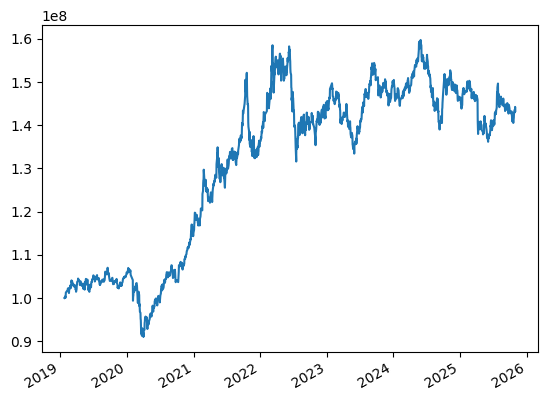

In [21]:
benchmark_result.v.plot()

# 确定超参

## 风险和cost系数

In [22]:
# # === MPO 策略核心参数网格搜索 (Grid Search) ===
# import logging
# import warnings
# import itertools
# import pandas as pd
# import numpy as np
# import cvxportfolio as cp
# from cvxportfolio.policies import RobustMultiPeriodOpt

# # 屏蔽警告
# warnings.filterwarnings("ignore", message=".*DPP.*", category=UserWarning)
# logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')

# print('\n=== 开始运行参数网格搜索 ===')

# # 1. 定义你要搜索的参数网格
# gamma_risks_coarse = [5, 10, 100, 1000]
# gamma_tcosts_coarse = [1,50,100]

# # 2. 截取测试时间段 (强烈建议网格搜索期间只用 1~2 年数据！)
# # 比如这里截取 2019-01-01 到 2020-12-31，大约 500 个交易日
# test_start = '2019-01-01'
# test_end = '2020-12-31'
# test_returns = clean_historical_returns.loc[test_start:test_end]

# # 3. 初始化相同的 Returns 模型和资金
# best_alpha_model = cp.returns.ReturnsForecast(
#     returns=return_predictions, 
#     delta=0.000001, 
#     gamma_decay=2.0
# )

# start_portfolio = pd.Series(0.0, index=clean_historical_returns.columns)
# if 'USDOLLAR' not in start_portfolio.index:
#     start_portfolio['USDOLLAR'] = 0.0
# start_portfolio['USDOLLAR'] = 1.0
# test_portfolio = start_portfolio * 1e8

# # 4. 准备记录结果的列表
# results_list = []
# total_runs = len(gamma_risks_coarse) * len(gamma_tcosts_coarse)
# current_run = 1

# print(f'总计需要测试 {total_runs} 组参数。测试区间: {test_start} 至 {test_end}')

# # 5. 开始双重循环搜索
# for g_risk, g_cost in itertools.product(gamma_risks_coarse, gamma_tcosts_coarse):
#     print(f"\n[{current_run}/{total_runs}] 正在测试参数组合: gamma_risk={g_risk}, gamma_tcost={g_cost} ...")
    
#     # 构建当前参数下的策略
#     # 💡 提示: 这里把 lookahead_periods 降为 2，可以大幅提速，同时保留了 MPO 的多期特性
#     test_policy = RobustMultiPeriodOpt(
#         return_forecast=best_alpha_model,
#         costs=[
#             g_risk * risk_model,             
#             g_cost * commission_model,       
#             g_cost * slippage_model,         
#             margin_cost_model             
#         ],
#         constraints=[cp.MarginMaxLeverage(margin_map=margin_map, limit=0.8)], 
#         trading_times=list(test_returns.index),
#         lookahead_periods=2, 
#         terminal_weights=None,
#         solver='CLARABEL',
#         solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7} 
#     )
    
#     # 运行回测
#     try:
#         res = simulator.run_backtest(
#             test_portfolio.copy(), 
#             policy=test_policy, 
#             start_time=test_returns.index[0], 
#             end_time=test_returns.index[-1]
#         )
        
#         # 提取关键指标
#         ann_ret = res.returns.mean() * 252 * 100            # 年化收益率 (%)
#         ann_vol = res.returns.std() * np.sqrt(252) * 100    # 年化波动率 (%)
#         sharpe = ann_ret / ann_vol if ann_vol > 0 else 0    # 夏普比率
#         max_dd = res.max_drawdown * 100                     # 最大回撤 (%)
#         turnover = res.turnover.mean() * 252 * 100          # 年化换手率 (%)
        
#         print(f"  --> 结果: 夏普 {sharpe:.2f} | 收益 {ann_ret:.2f}% | 换手率 {turnover:.0f}%")
        
#         # 存入结果字典
#         results_list.append({
#             'gamma_risk': g_risk,
#             'gamma_tcost': g_cost,
#             'Sharpe': sharpe,
#             'Ann_Return(%)': ann_ret,
#             'Ann_Vol(%)': ann_vol,
#             'Max_Drawdown(%)': max_dd,
#             'Turnover(%)': turnover
#         })
        
#     except Exception as e:
#         print(f"  --> ❌ 测试失败，错误信息: {e}")
#         results_list.append({
#             'gamma_risk': g_risk,
#             'gamma_tcost': g_cost,
#             'Sharpe': np.nan, 'Ann_Return(%)': np.nan, 'Ann_Vol(%)': np.nan, 
#             'Max_Drawdown(%)': np.nan, 'Turnover(%)': np.nan
#         })
        
#     current_run += 1

# # 6. 将结果转为 DataFrame 并按夏普排序
# grid_results_df = pd.DataFrame(results_list)
# grid_results_df = grid_results_df.sort_values(by='Sharpe', ascending=False).reset_index(drop=True)

# print("\n🎉 网格搜索完成！以下是排行榜 Top 10：")
# print(grid_results_df.head(10).to_string())



In [23]:
# # === 终极精细网格搜索：锁定黄金参数 (已修正) ===
# import itertools
# import pandas as pd
# import numpy as np
# import cvxportfolio as cp
# from cvxportfolio.policies import RobustMultiPeriodOpt

# print('\n=== 开始第三轮：精细网格搜索 ===')

# # 1. 缩小包围圈：只在黄金区间内搜索
# gamma_risks_fine = [1, 5, 10]
# gamma_tcosts_fine = [15, 20, 30, 40, 50, 60, 80]  # 密集排查 10 ~ 100 的地带

# # 2. 依然使用 Returns 模型和测试数据
# best_alpha_model = cp.returns.ReturnsForecast(
#     returns=return_predictions, 
#     delta=0.000001, 
#     gamma_decay=2.0
# )

# results_list = []
# total_runs = len(gamma_risks_fine) * len(gamma_tcosts_fine)
# current_run = 1

# for g_risk, g_cost in itertools.product(gamma_risks_fine, gamma_tcosts_fine):
#     print(f"[{current_run}/{total_runs}] 风险: {g_risk}, 成本: {g_cost} ...")
    
#     test_policy = RobustMultiPeriodOpt(
#         return_forecast=best_alpha_model,
#         costs=[
#             g_risk * risk_model,             
#             g_cost * commission_model,       
#             g_cost * slippage_model,         
#             margin_cost_model             
#         ],
#         constraints=[[cp.MarginMaxLeverage(margin_map=margin_map, limit=0.8)]
            
#         ], 
#         trading_times=list(test_returns.index),
#         lookahead_periods=2, 
#         terminal_weights=None,  # 👉 已经补上这里了！！！
#         solver='CLARABEL',
#         solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7} 
#     )
    
#     try:
#         res = simulator.run_backtest(
#             test_portfolio.copy(), policy=test_policy, 
#             start_time=test_returns.index[0], end_time=test_returns.index[-1]
#         )
        
#         ann_ret = res.returns.mean() * 252 * 100            
#         ann_vol = res.returns.std() * np.sqrt(252) * 100    
#         sharpe = ann_ret / ann_vol if ann_vol > 0 else 0    
#         turnover = res.turnover.mean() * 252 * 100          
        
#         print(f"  -> 夏普: {sharpe:.2f} | 收益: {ann_ret:.2f}% | 换手: {turnover:.0f}%")
        
#         results_list.append({
#             'gamma_risk': g_risk, 'gamma_tcost': g_cost,
#             'Sharpe': sharpe, 'Return(%)': ann_ret, 'Turnover(%)': turnover
#         })
        
#     except Exception as e:
#         print(f"  -> ❌ 失败: {e}")
        
#     current_run += 1

# # 打印最终决战排行榜
# grid_results_df = pd.DataFrame(results_list).sort_values(by='Sharpe', ascending=False).reset_index(drop=True)
# print("\n🏆 黄金区间精细搜索排行榜 Top 10：")
# print(grid_results_df.head(10).to_string(index=False))

## 约束系数

In [24]:
# import pandas as pd
# import numpy as np
# import cvxportfolio as cp
# import itertools
# import warnings
# from cvxportfolio.policies import RobustMultiPeriodOpt 

# # 屏蔽底层编译性能警告
# warnings.filterwarnings("ignore", message=".*DPP.*", category=UserWarning)

# print("=== 🛡️ 风控边界 (Limit) 网格搜索：寻找最佳资金利用率 ===\n")

# # ==========================================
# # 1. 基础环境设置 (请填入你之前测出来的最佳 Alpha 和 Gamma 参数)
# # ==========================================
# # 假设这是你上一轮得出的优秀参数，如果没有跑完可以用这组作为强力基准：
# BEST_GAMMA_RISK = 5.0
# BEST_GAMMA_TCOST = 80.0
# BEST_DECAY = 1.0     
# BEST_DELTA = 0.0001  

# # 获取风险资产列表
# risky_assets = [c for c in return_predictions.columns if c != 'USDOLLAR']

# # 准备资金
# start_portfolio = pd.Series(0.0, index=clean_historical_returns.columns)
# if 'USDOLLAR' not in start_portfolio.index:
#     start_portfolio['USDOLLAR'] = 0.0
# start_portfolio['USDOLLAR'] = 1.0
# initial_portfolio = start_portfolio * 1e8

# # 固定的收益模型与成本模型
# alpha_model = cp.returns.ReturnsForecast(
#     returns=return_predictions, 
#     delta=BEST_DELTA, 
#     gamma_decay=BEST_DECAY
# )

# fixed_costs = [
#     BEST_GAMMA_RISK * risk_model,
#     BEST_GAMMA_TCOST * commission_model,
#     BEST_GAMMA_TCOST * slippage_model,
#     margin_cost_model
# ]

# # ==========================================
# # 2. 构造 Limit 搜索网格
# # ==========================================
# # 名义本金杠杆限制 (2倍 到 5倍)
# leverage_limits = [5.0,6.0,7.0,8.0,9.0,10.0]  

# # 真实保证金占用限制 (40% 到 90%)
# margin_limits = [0.4, 0.6, 0.8, 0.9]    

# # 截取 1 年的数据进行快速测试 (2020年行情波动大，试金石最好)
# test_start = '2020-01-01'
# test_end = '2020-12-31'
# test_returns = clean_historical_returns.loc[test_start:test_end]

# total_runs = len(leverage_limits) * len(margin_limits)
# current_run = 1
# results_data = []

# print(f"✅ 准备就绪，共 {total_runs} 组风控参数对。将在 {test_start} 至 {test_end} 期间进行搜索。")
# print("⏳ 正在运行批量回测，请稍候...\n")

# # ==========================================
# # 3. 执行双重循环回测
# # ==========================================
# for lev_lim, marg_lim in itertools.product(leverage_limits, margin_limits):
#     print(f"[{current_run}/{total_runs}] 正在测试 -> 名义杠杆上限: {lev_lim}x | 保证金占用上限: {marg_lim*100}%")
    
#     # 动态组装当前循环的约束条件
#     test_constraints = [
#         # 名义杠杆锁
#         cp.LeverageLimit(limit=lev_lim),
        
#         # 真实保证金锁 (注意加上 asset_list 防止之前的 w_bench 报错重演！)
#         cp.MarginMaxLeverage(margin_map=margin_map, limit=marg_lim, asset_list=risky_assets),
#     ]
    
#     # 构建当前策略
#     test_policy = RobustMultiPeriodOpt(
#         return_forecast=alpha_model,
#         costs=fixed_costs,
#         constraints=test_constraints, 
#         trading_times=list(test_returns.index),
#         lookahead_periods=2,       # 👉 保持为 2，让回测跑得飞快
#         terminal_weights=None, 
#         solver='CLARABEL',
#         solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7}
#     )

#     # 运行回测
#     try:
#         res = simulator.run_backtest(
#             initial_portfolio.copy(), 
#             policy=test_policy, 
#             start_time=test_returns.index[0], 
#             end_time=test_returns.index[-1]
#         )
        
#         # 提取指标
#         ann_return = res.returns.mean() * 252 * 100 
#         ann_vol = res.returns.std() * np.sqrt(252) * 100
#         sharpe = ann_return / ann_vol if ann_vol > 0 else 0
#         max_dd = res.max_drawdown 
#         if max_dd < 1: max_dd *= 100
#         turnover = res.turnover.mean() * 252 * 100
        
#         print(f"  -> 🏆 夏普: {sharpe:.2f} | 收益: {ann_return:.2f}% | 回撤: {max_dd:.2f}% | 波动率: {ann_vol:.2f}%")
        
#         results_data.append({
#             'Leverage_Limit': lev_lim,
#             'Margin_Limit': marg_lim,
#             'Sharpe 🏆': sharpe,
#             'Return %': ann_return,
#             'Max DD %': max_dd,
#             'Ann Vol %': ann_vol,
#             'Turnover %': turnover
#         })
        
#     except Exception as e:
#         print(f"  -> ❌ 测试失败: {e}")
        
#     current_run += 1

# # ==========================================
# # 4. 生成排行榜
# # ==========================================
# if results_data:
#     df_metrics = pd.DataFrame(results_data)
#     print("\n" + "="*70)
#     print("🏆 资金风控边界 (Limits) 网格搜索结果 TOP 10:")
#     print("="*70)
#     # 按夏普比率降序排列
#     top_results = df_metrics.sort_values(by='Sharpe 🏆', ascending=False).head(10)
#     print(top_results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
# else:
#     print("\n❌ 所有测试均未成功生成结果。")

# SPO

---- 当前单元格: SPO (单期优化) 对照组 section ----
⏳ 开始构建 SPO 策略...
🚀 开始运行 SPO 回测 (2019-01-24 至 2025-10-31)...


c:\Users\CtaBackup\anaconda3\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)
c:\Users\CtaBackup\anaconda3\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)
c:\Users\CtaBackup\anaconda3\Lib\site-packages\cvxpy\reductions\solvers\solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. 


🏆 === SPO (单期优化) 回测结果 ===
Number of periods                              1640
Initial timestamp               2019-01-24 00:00:00
Final timestamp                 2025-10-31 00:00:00
Portfolio return (%)                         10.557
Excess return (%)                            10.557
Excess risk (%)                              12.279
Sharpe ratio                                  0.860
Max. drawdown                                16.583
Turnover (%)                              1,380.430
Average policy time (sec)                     0.062
Average simulator time (sec)                  0.009


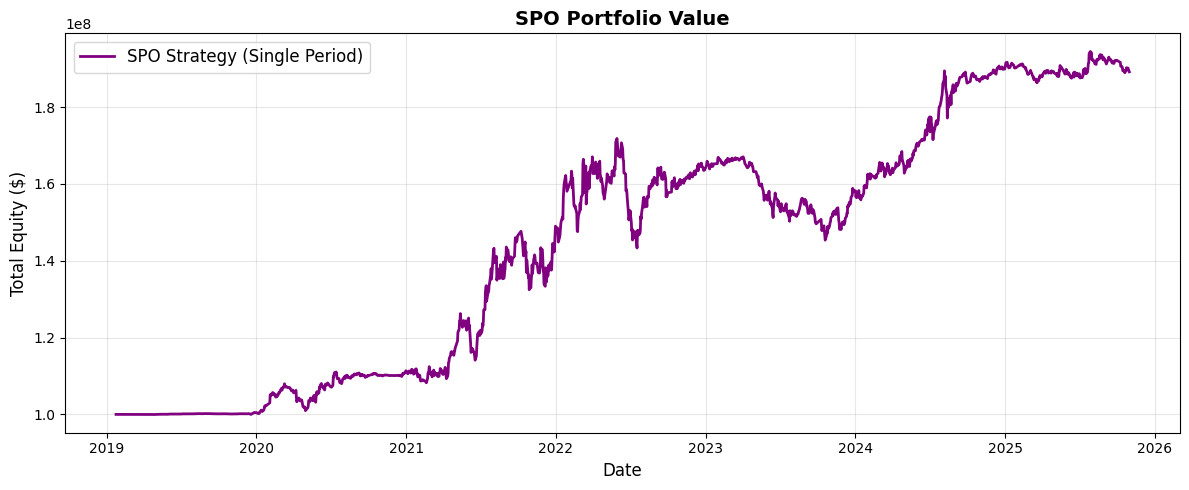

In [31]:
import pandas as pd
import numpy as np
import cvxportfolio as cp
from cvxportfolio.policies import SinglePeriodOpt
import matplotlib.pyplot as plt

print("---- 当前单元格: SPO (单期优化) 对照组 section ----")
print("⏳ 开始构建 SPO 策略...")

# ==========================================
# 1. 收益与成本模型获取 (复用之前环境中的变量)
# ==========================================
try:
    spo_alpha = alpha_model
except NameError:
    spo_alpha = cp.returns.ReturnsForecast(
        returns=return_predictions, delta=0.000001, gamma_decay=2.0
    )

try:
    spo_costs = fixed_costs
except NameError:
    # 假设你的 cost 模型在内存中叫这些名字
    spo_costs = [
        5.0 * risk_model,
        80.0 * commission_model,
        80.0 * slippage_model,
        margin_cost_model,
    ]

# 👉 核心补丁 1：动态赋予 optimization_log 方法，骗过底层 SPO 的日志系统
for cost in spo_costs:
    if not hasattr(cost, 'optimization_log'):
        cost.optimization_log = lambda t: 0.0

# ==========================================
# 2. 约束条件 (严格对齐 MPO)
# ==========================================
# 提取风险资产列表 (如果环境中没有，动态生成)
risky_assets = [c for c in clean_historical_returns.columns if c != 'USDOLLAR']

spo_constraints = [
    cp.MarginMaxLeverage(margin_map=margin_map, limit=0.8, asset_list=risky_assets),
    cp.TradeAbsoluteLimit(0.1) 
]

# ==========================================
# 3. 实例化 SPO 策略
# ==========================================
spo_policy = SinglePeriodOpt(
    return_forecast=spo_alpha,
    costs=spo_costs,
    constraints=spo_constraints,
    solver='CLARABEL',
    solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7},
)

# ==========================================
# 4. 构建初始组合 (1亿满现金起始)
# ==========================================
start_portfolio = pd.Series(0.0, index=clean_historical_returns.columns)
if 'USDOLLAR' not in start_portfolio.index:
    start_portfolio['USDOLLAR'] = 0.0
start_portfolio['USDOLLAR'] = 1.0
initial_portfolio = start_portfolio * 1e8

# 如果环境中没有 start_date 和 end_date，直接从数据截取
try:
    s_date = start_date
    e_date = end_date
except NameError:
    s_date = clean_historical_returns.index[0]
    e_date = clean_historical_returns.index[500]

print(f"🚀 开始运行 SPO 回测 ({s_date.date()} 至 {e_date.date()})...")

# ==========================================
# 5. 运行回测
# ==========================================
try:
    # 👉 核心补丁 2：全部使用关键字参数，防止 datetime 与对象强行比大小
    spo_result = simulator.run_backtest(
        initial_portfolio=initial_portfolio.copy(),
        policy=spo_policy,              
        start_time=s_date,          
        end_time=e_date               
    )

    # 输出结果
    print("\n🏆 === SPO (单期优化) 回测结果 ===")
    spo_result.summary()

    # 绘图示例
    plt.figure(figsize=(12, 5))
    plt.plot(spo_result.v.index, spo_result.v.values, color='purple', linewidth=2, label='SPO Strategy (Single Period)')
    plt.title('SPO Portfolio Value', fontsize=14, fontweight='bold')
    plt.ylabel("Total Equity ($)", fontsize=12)
    plt.xlabel("Date", fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"\n❌ SPO 回测运行失败: {e}")
    import traceback
    traceback.print_exc()

# 结果对比


=== 开始运行最终全量回测 ===
⏳ 正在运行全量历史数据，参数 Risk=5.0, TCost=80.0...
✅ 回测完美结束！

Number of periods                              1640
Initial timestamp               2019-01-24 00:00:00
Final timestamp                 2025-10-31 00:00:00
Portfolio return (%)                         11.266
Excess return (%)                            11.266
Excess risk (%)                              14.934
Sharpe ratio                                  0.755
Max. drawdown                                26.742
Turnover (%)                              3,820.225
Average policy time (sec)                     0.112
Average simulator time (sec)                  0.009


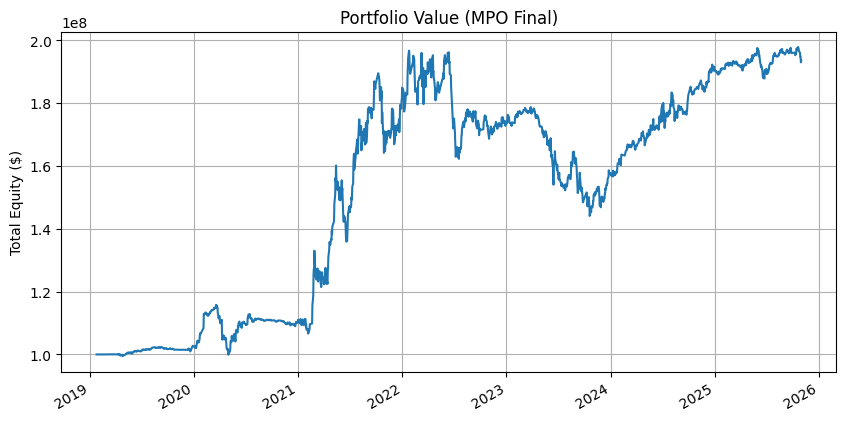

In [35]:
# === 最终版 MPO 全量历史回测 ===
import logging
import warnings
import pandas as pd
import numpy as np
import cvxportfolio as cp
from cvxportfolio.policies import RobustMultiPeriodOpt

# 屏蔽警告
warnings.filterwarnings("ignore", message=".*DPP.*", category=UserWarning)
logging.basicConfig(level=logging.WARNING, format='%(levelname)s: %(message)s')

print('\n=== 开始运行最终全量回测 ===')

# 1. 黄金参数
best_gamma_risk = 5.0
best_gamma_tcost = 80.0

# 2. 实例化 Returns 模型
best_alpha_model = cp.returns.ReturnsForecast(
    returns=return_predictions, 
    delta=0.000001, 
    gamma_decay=2.0
)

# 3. 实例化策略
final_policy = RobustMultiPeriodOpt(
    return_forecast=best_alpha_model,
    costs=[
        best_gamma_risk * risk_model,             
        best_gamma_tcost * commission_model,       
        best_gamma_tcost * slippage_model,         
        margin_cost_model             
    ],
    constraints=[
        cp.MarginMaxLeverage(margin_map=margin_map, limit=0.9),
        # cp.LeverageLimit(limit=5)
    ],
    trading_times=list(clean_historical_returns.index),
    lookahead_periods=2, 
    terminal_weights=None,
    solver='CLARABEL',
    solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7} 
)

# 4. 构建初始投资组合 (1e8 满现金)
start_portfolio = pd.Series(0.0, index=clean_historical_returns.columns)
if 'USDOLLAR' not in start_portfolio.index:
    start_portfolio['USDOLLAR'] = 0.0
start_portfolio['USDOLLAR'] = 1.0
initial_portfolio = start_portfolio * 1e8

# 5. 运行全量回测！
try:
    print(f'⏳ 正在运行全量历史数据，参数 Risk={best_gamma_risk}, TCost={best_gamma_tcost}...')
    # 注意这里用的是 clean_historical_returns (全部数据)
    res = simulator.run_backtest(
        initial_portfolio, 
        policy=final_policy, 
        start_time=clean_historical_returns.index[0], 
        end_time=clean_historical_returns.index[-1]
    )
    print('✅ 回测完美结束！\n')
    
    # 打印精美摘要
    res.summary()
    
    # 画出令人激动的资金曲线图 (如果是在 Jupyter 中)
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 5))
        res.v.plot(title="Portfolio Value (MPO Final)")
        plt.ylabel("Total Equity ($)")
        plt.grid(True)
        plt.show()
    except:
        pass
        
except Exception as e:
    print('❌ 发生异常:', e)

In [36]:
# === 增加带杠杆限制的策略比较 ===
# 设置matplotlib中文字体支持
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']  # 优先使用SimHei显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

print("="*80)
print("=== 🏆 四策略完整对比：Base MPO vs Lev5 MPO vs Lev10 MPO vs Benchmark ===")
print("="*80)

# 创建 Lev5 版本
policy_lev5 = RobustMultiPeriodOpt(
    return_forecast=best_alpha_model,
    costs=[
        best_gamma_risk * risk_model,
        best_gamma_tcost * commission_model,
        best_gamma_tcost * slippage_model,
        margin_cost_model
    ],
    constraints=[
        cp.MarginMaxLeverage(margin_map=margin_map, limit=0.9),
        cp.LeverageLimit(limit=5)
    ],
    trading_times=list(clean_historical_returns.index),
    lookahead_periods=2,
    terminal_weights=None,
    solver='CLARABEL',
    solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7}
)

# 创建 Lev10 版本
policy_lev10 = RobustMultiPeriodOpt(
    return_forecast=best_alpha_model,
    costs=[
        best_gamma_risk * risk_model,
        best_gamma_tcost * commission_model,
        best_gamma_tcost * slippage_model,
        margin_cost_model
    ],
    constraints=[
        cp.MarginMaxLeverage(margin_map=margin_map, limit=0.9),
        cp.LeverageLimit(limit=10)
    ],
    trading_times=list(clean_historical_returns.index),
    lookahead_periods=2,
    terminal_weights=None,
    solver='CLARABEL',
    solver_opts={'tol_gap_abs': 1e-7, 'tol_gap_rel': 1e-7}
)

print("\n⏳ 正在运行 Lev5 MPO 全量回测...")
res_lev5 = simulator.run_backtest(
    initial_portfolio,
    policy=policy_lev5,
    start_time=clean_historical_returns.index[0],
    end_time=clean_historical_returns.index[-1]
)
print("✅ Lev5 MPO 回测完成！")

print("⏳ 正在运行 Lev10 MPO 全量回测...")
res_lev10 = simulator.run_backtest(
    initial_portfolio,
    policy=policy_lev10,
    start_time=clean_historical_returns.index[0],
    end_time=clean_historical_returns.index[-1]
)
print("✅ Lev10 MPO 回测完成！\n")


=== 🏆 四策略完整对比：Base MPO vs Lev5 MPO vs Lev10 MPO vs Benchmark ===

⏳ 正在运行 Lev5 MPO 全量回测...
✅ Lev5 MPO 回测完成！
⏳ 正在运行 Lev10 MPO 全量回测...
✅ Lev10 MPO 回测完成！



📊 【五策略绩效对比表】
          Base MPO  Lev5 MPO  Lev10 MPO  Benchmark       SPO
年化收益 (%)    11.266     7.577     10.401      6.204    10.557
年化波动 (%)    14.934     8.525     13.707     11.576    12.279
夏普比率         0.754     0.889      0.759      0.536     0.860
最大回撤 (%)    26.742    13.550     25.161     16.985    16.583
年化换手 (%)  3820.225  2177.249   3482.368    265.595  1380.430
平均杠杆 (x)     5.038     3.299      4.716      1.000     4.215




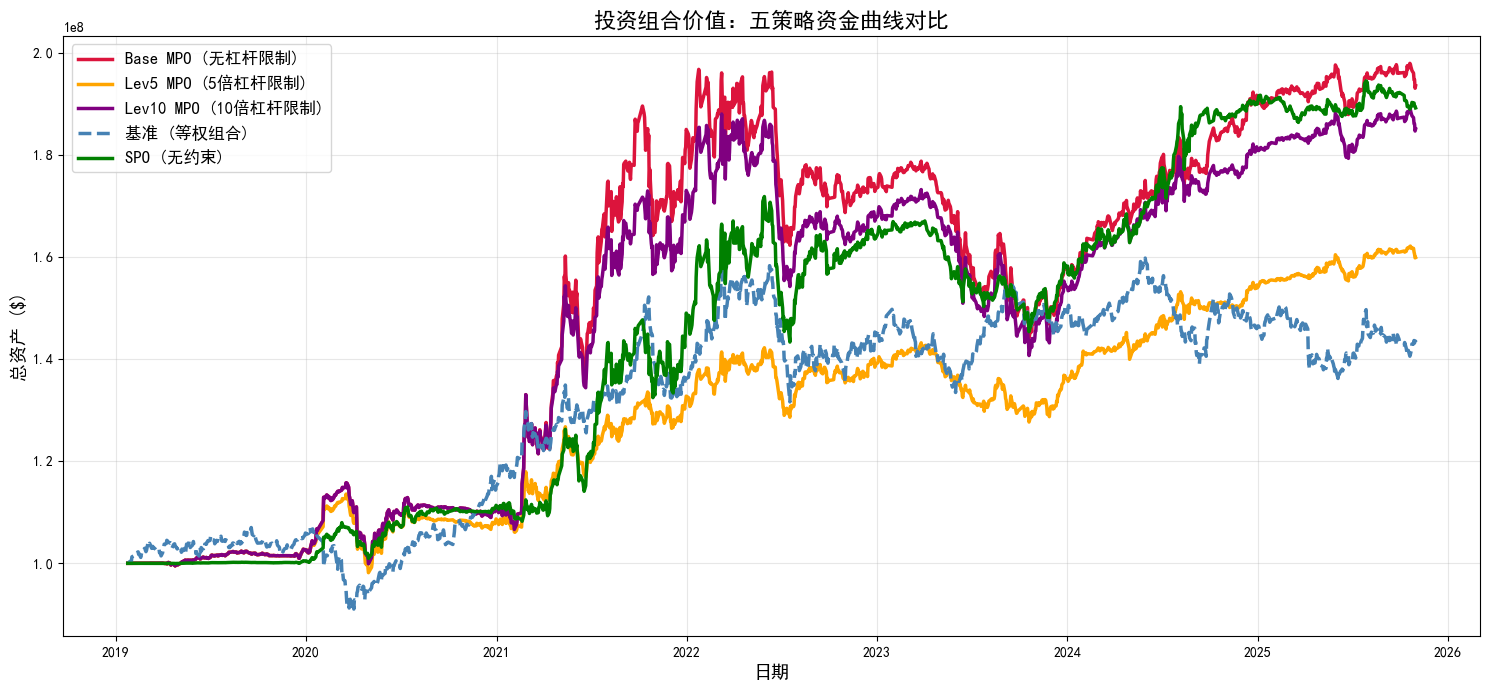

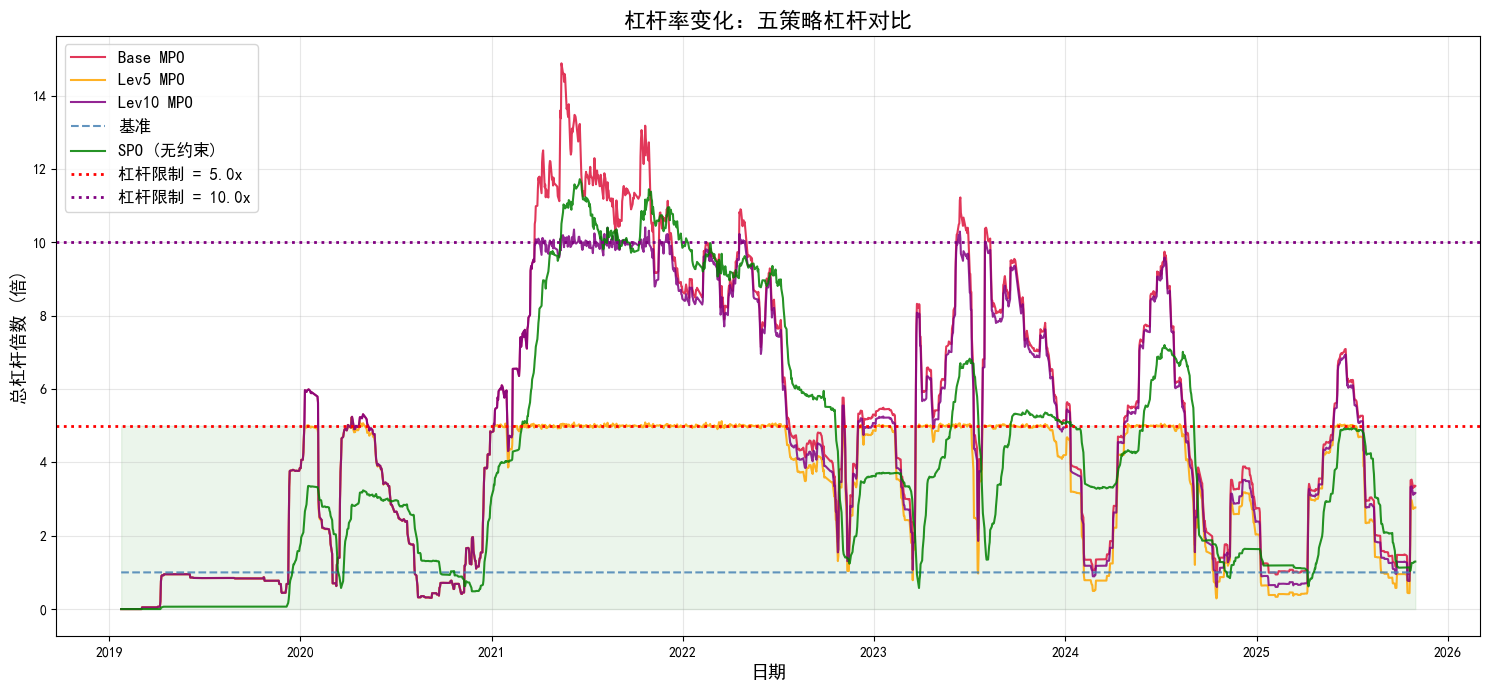

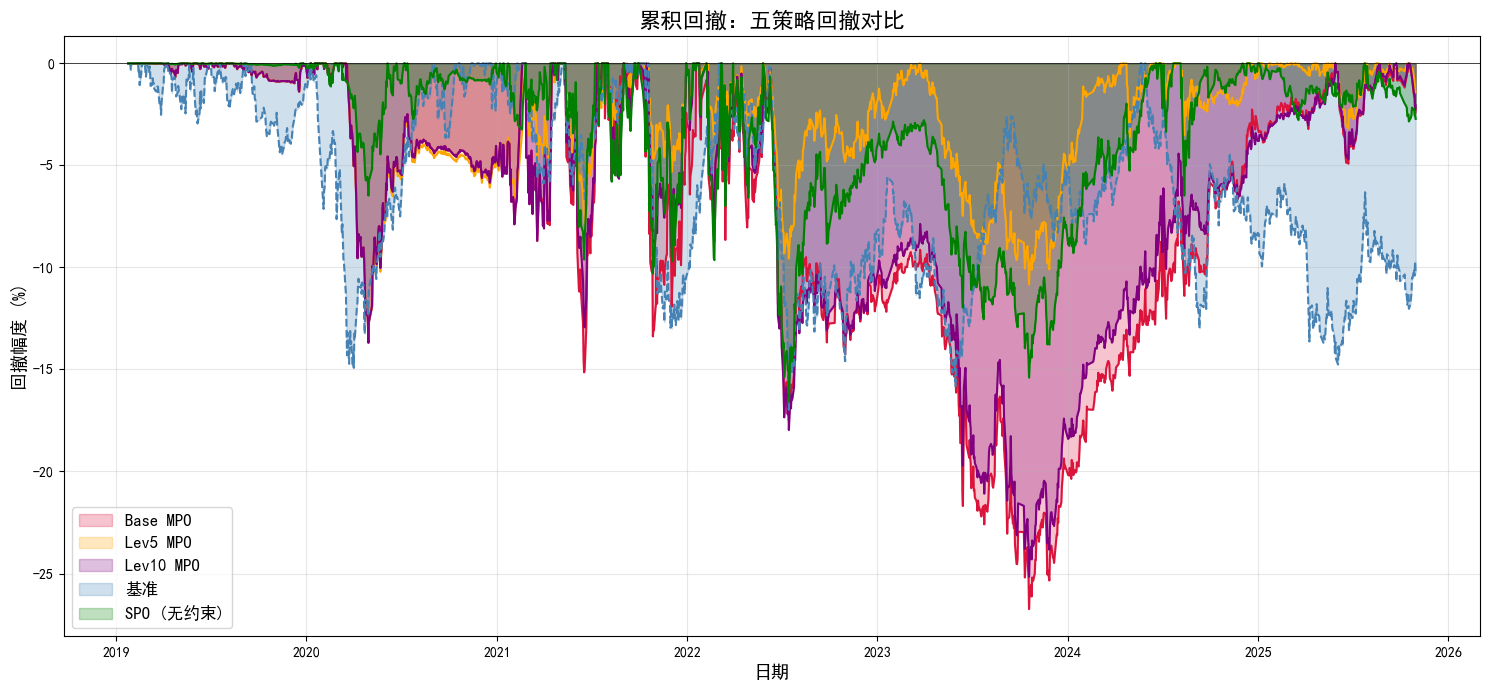


✅ 五策略完整对比分析完成！

📋 【各策略重仓标的（按平均权重排序）】

正在生成持仓可视化图表...


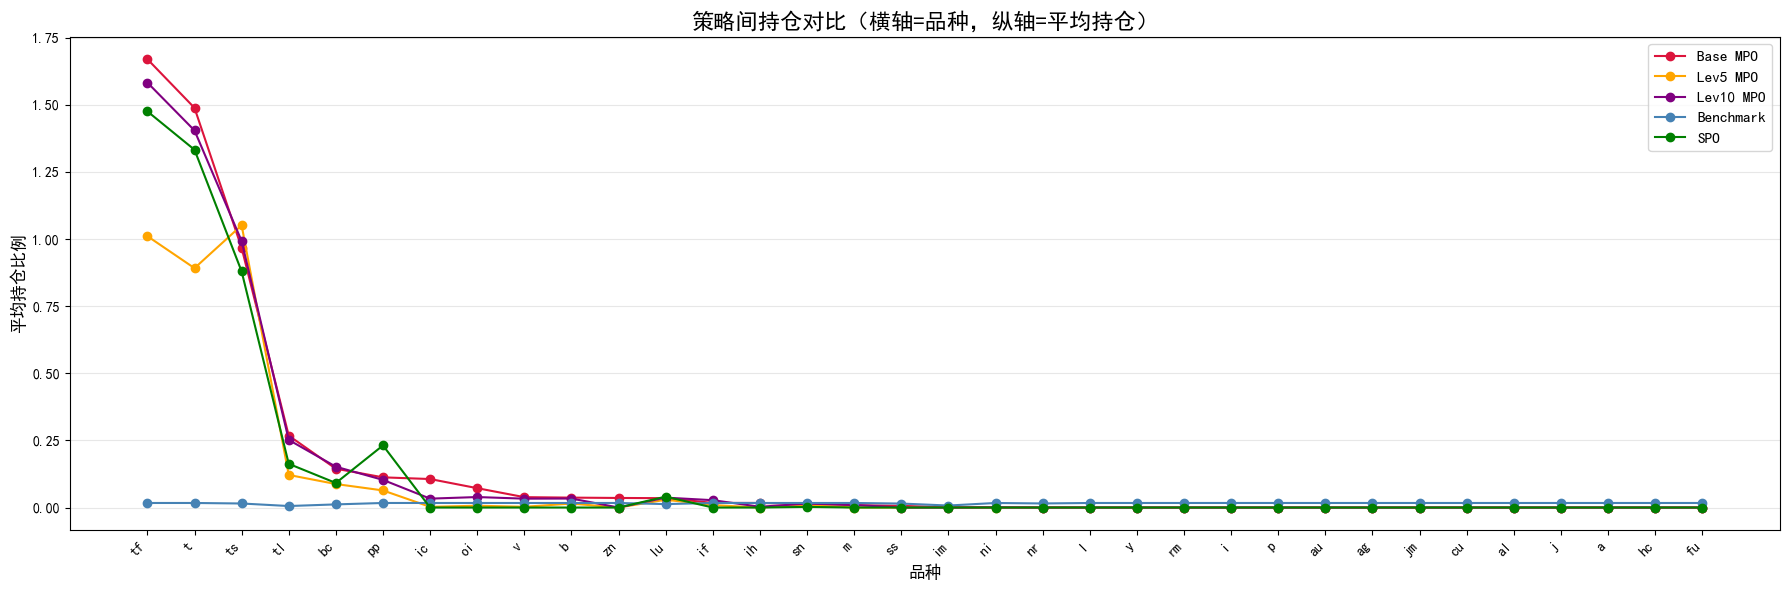

In [37]:

# 定义统一的指标提取函数
def summary_metrics(r):
    ann_ret = r.returns.mean() * 252 * 100
    ann_vol = r.returns.std() * np.sqrt(252) * 100
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = r.max_drawdown
    if max_dd < 1:
        max_dd *= 100
    turnover = r.turnover.mean() * 252 * 100
    # 平均杠杆
    lev = r.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1).mean()
    return [ann_ret, ann_vol, sharpe, max_dd, turnover, lev]

metrics_comp = pd.DataFrame({
    'Base MPO': summary_metrics(res),
    'Lev5 MPO': summary_metrics(res_lev5),
    'Lev10 MPO': summary_metrics(res_lev10),
    'Benchmark': summary_metrics(benchmark_result),
    'SPO': summary_metrics(spo_result)
}, index=['年化收益 (%)', '年化波动 (%)', '夏普比率', '最大回撤 (%)', '年化换手 (%)', '平均杠杆 (x)'])

print("="*80)
print("📊 【五策略绩效对比表】")
print("="*80)
print(metrics_comp.round(3).to_string())
print("\n")

# ==========================================
# 图表1：四策略资金曲线对比
# ==========================================
plt.figure(figsize=(15, 7))

plt.plot(res.v.index, res.v.values, label='Base MPO (无杠杆限制)', color='crimson', linewidth=2.5)
plt.plot(res_lev5.v.index, res_lev5.v.values, label='Lev5 MPO (5倍杠杆限制)', color='orange', linewidth=2.5)
plt.plot(res_lev10.v.index, res_lev10.v.values, label='Lev10 MPO (10倍杠杆限制)', color='purple', linewidth=2.5)
plt.plot(benchmark_result.v.index, benchmark_result.v.values, label='基准 (等权组合)', 
         color='steelblue', linestyle='--', linewidth=2.5)
plt.plot(spo_result.v.index, spo_result.v.values, label='SPO (无约束)', color='green', linewidth=2.5)

plt.title('投资组合价值：五策略资金曲线对比', fontsize=16, fontweight='bold')
plt.ylabel('总资产 ($)', fontsize=13)
plt.xlabel('日期', fontsize=13)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 图表2：四策略杠杆对比
# ==========================================
lev_base = res.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1)
lev_lev5 = res_lev5.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1)
lev_lev10 = res_lev10.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1)
lev_bench = benchmark_result.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1)
lev_spo = spo_result.w.drop(columns=['USDOLLAR'], errors='ignore').abs().sum(axis=1)
plt.figure(figsize=(15, 7))
plt.plot(lev_base.index, lev_base, label='Base MPO', color='crimson', linewidth=1.5, alpha=0.85)
plt.plot(lev_lev5.index, lev_lev5, label='Lev5 MPO', color='orange', linewidth=1.5, alpha=0.85)
plt.plot(lev_lev10.index, lev_lev10, label='Lev10 MPO', color='purple', linewidth=1.5, alpha=0.85)
plt.plot(lev_bench.index, lev_bench, label='基准', color='steelblue', linestyle='--', linewidth=1.5, alpha=0.85)
plt.plot(lev_spo.index, lev_spo, label='SPO (无约束)', color='green', linewidth=1.5, alpha=0.85)
plt.axhline(5, color='red', linestyle=':', linewidth=2, label='杠杆限制 = 5.0x')
plt.axhline(10, color='purple', linestyle=':', linewidth=2, label='杠杆限制 = 10.0x')
plt.fill_between(lev_base.index, 0, 5, alpha=0.08, color='green')

plt.title('杠杆率变化：五策略杠杆对比', fontsize=16, fontweight='bold')
plt.ylabel('总杠杆倍数 (倍)', fontsize=13)
plt.xlabel('日期', fontsize=13)
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ==========================================
# 图表3：四策略累积回撤对比
# ==========================================
def compute_drawdown(returns):
    """计算累积回撤曲线"""
    cum_returns = (1 + returns).cumprod()
    running_max = cum_returns.cummax()
    drawdown = (cum_returns - running_max) / running_max * 100
    return drawdown

dd_base = compute_drawdown(res.returns)
dd_lev5 = compute_drawdown(res_lev5.returns)
dd_lev10 = compute_drawdown(res_lev10.returns)
dd_spo = compute_drawdown(spo_result.returns)
dd_bench = compute_drawdown(benchmark_result.returns)

plt.figure(figsize=(15, 7))
plt.fill_between(dd_base.index, dd_base, 0, alpha=0.25, color='crimson', label='Base MPO')
plt.plot(dd_base.index, dd_base, color='crimson', linewidth=1.5)

plt.fill_between(dd_lev5.index, dd_lev5, 0, alpha=0.25, color='orange', label='Lev5 MPO')
plt.plot(dd_lev5.index, dd_lev5, color='orange', linewidth=1.5)

plt.fill_between(dd_lev10.index, dd_lev10, 0, alpha=0.25, color='purple', label='Lev10 MPO')
plt.plot(dd_lev10.index, dd_lev10, color='purple', linewidth=1.5)

plt.fill_between(dd_bench.index, dd_bench, 0, alpha=0.25, color='steelblue', label='基准')
plt.plot(dd_bench.index, dd_bench, color='steelblue', linewidth=1.5, linestyle='--')

plt.fill_between(dd_spo.index, dd_spo, 0, alpha=0.25, color='green', label='SPO (无约束)')
plt.plot(dd_spo.index, dd_spo, color='green', linewidth=1.5)

plt.title('累积回撤：五策略回撤对比', fontsize=16, fontweight='bold')
plt.ylabel('回撤幅度 (%)', fontsize=13)
plt.xlabel('日期', fontsize=13)
plt.legend(fontsize=12, loc='lower left')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


print("\n" + "="*80)
print("✅ 五策略完整对比分析完成！")
print("="*80)

# === 输出各策略重仓标的 ===
print("\n" + "="*80)
print("📋 【各策略重仓标的（按平均权重排序）】")
print("="*80)

def get_top_holdings_visual(result_obj, strategy_name, top_n=8):
    """
    获取策略的重仓标的，返回权重Series供图表使用
    """
    # 获取权重矩阵
    w = result_obj.w.drop(columns=['USDOLLAR'], errors='ignore')
    
    # 计算平均权重
    avg_weights = w.abs().mean().sort_values(ascending=False)
    
    return avg_weights

# 获取各策略持仓
print("\n正在生成持仓可视化图表...")
weights_base = get_top_holdings_visual(res, "Base MPO (无杠杆限制)", top_n=8)
weights_lev5 = get_top_holdings_visual(res_lev5, "Lev5 MPO (5倍杠杆限制)", top_n=8)
weights_lev10 = get_top_holdings_visual(res_lev10, "Lev10 MPO (10倍杠杆限制)", top_n=8)
weights_bench = get_top_holdings_visual(benchmark_result, "基准 (等权组合)", top_n=8)
weights_spo = get_top_holdings_visual(spo_result, "SPO (无约束)", top_n=8)

top_n = 20
top_assets = list(pd.Index(
    list(weights_base.head(top_n).index) +
    list(weights_lev5.head(top_n).index) +
    list(weights_lev10.head(top_n).index) +
    list(weights_bench.head(top_n).index) +
    list(weights_spo.head(top_n).index)
).unique())

# 构建用于绘制的 DataFrame（所有选中标的，缺失填 0）
df_plot = pd.DataFrame(index=top_assets)
df_plot['Base MPO'] = weights_base.reindex(top_assets).fillna(0)
df_plot['Lev5 MPO'] = weights_lev5.reindex(top_assets).fillna(0)
df_plot['Lev10 MPO'] = weights_lev10.reindex(top_assets).fillna(0)
df_plot['Benchmark'] = weights_bench.reindex(top_assets).fillna(0)
df_plot['SPO'] = weights_spo.reindex(top_assets).fillna(0)

plt.figure(figsize=(18, 6))
colors = {'Base MPO':'crimson', 'Lev5 MPO':'orange', 'Lev10 MPO':'purple', 'Benchmark':'steelblue', 'SPO':'green'}

for col in df_plot.columns:
    plt.plot(df_plot.index, df_plot[col].values, marker='o', label=col, color=colors.get(col, None))

plt.title('策略间持仓对比（横轴=品种，纵轴=平均持仓）', fontsize=16, fontweight='bold')
plt.ylabel('平均持仓比例', fontsize=12)
plt.xlabel('品种', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
